# Team 13

Authors: Mathis Kriwoluzky, Lennart Koch.

This notebook is our own work. Any other sources have been clearly marked and cited.

All authors contributed equally.

---

## 1. Set Up

In [39]:
from matplotlib import pyplot as plt
import seaborn as sns
import torch

BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


---
# 2. Load Data

In [40]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# this dataset already comes split in train and test
transform = transforms.ToTensor()
train = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test  = datasets.MNIST(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader  = DataLoader(test, batch_size=64, shuffle=False)

---
# 3. Data Exploration

### Anzahl der Samples


In [41]:
print("Train samples:", len(train))
print("Test samples:", len(test))

sample_img, sample_label = train[0]
print("Image shape:", sample_img.shape)

Train samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


### Visualisierung
Der folgende CodeBlock zeigt 10 Beispiele aus dem Datensatzt, wie die handgeschreibenen Zahlen in ihrer Form und Darstellung variieren können.

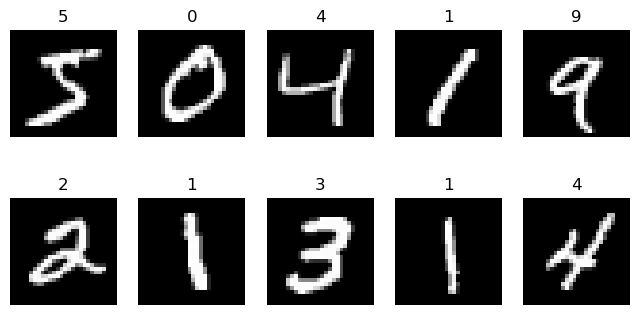

In [42]:
fig, axes = plt.subplots(2,5, figsize=(8,4))

for i, ax in enumerate(axes.flat):
    img, label = train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.show()

### PCA
Die PCA zeigt das ein trainiertes model nötig ist, da sich durch eine PCA zwar die klassen clustern, aber nicht perfekt von einander trennbar sind.

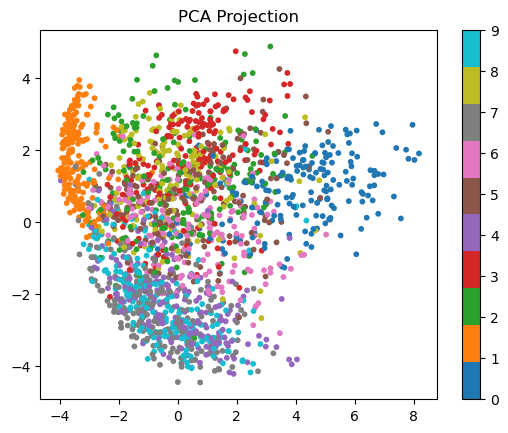

In [43]:
from sklearn.decomposition import PCA

# kleine Stichprobe
subset = torch.stack([train[i][0].view(-1) for i in range(2000)])
subset_labels = [train[i][1] for i in range(2000)]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(subset)

plt.scatter(X_pca[:,0], X_pca[:,1], c=subset_labels, cmap='tab10', s=10)
plt.colorbar()
plt.title("PCA Projection")
plt.show()

---
# 4. Data Model
Ziel: Klassifikation von Ziffern in einem Bild, von 0-9.

### Baseline Model mit Linearer KLassifikation

In [44]:
import torch.nn as nn

class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28*28, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

model = BaselineModel().to(DEVICE)

### Loss + Optimizer

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

---
# 5. Training

In [46]:
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.5439
Epoch 2, Loss: 0.3234
Epoch 3, Loss: 0.2953
Epoch 4, Loss: 0.2818
Epoch 5, Loss: 0.2737


### Los-Verlauf

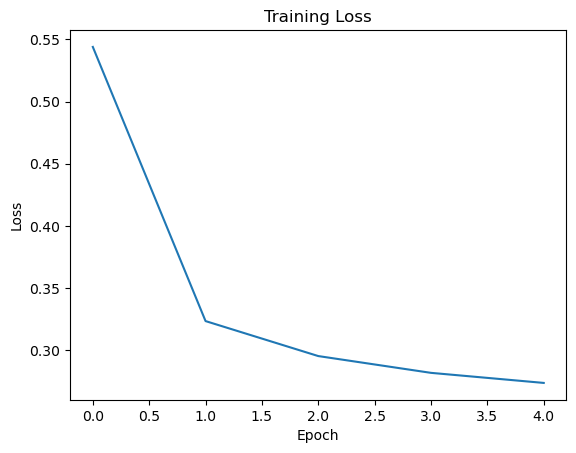

In [47]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

---
# 6. Evaluation

In [48]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9252


### Confusion Matrix

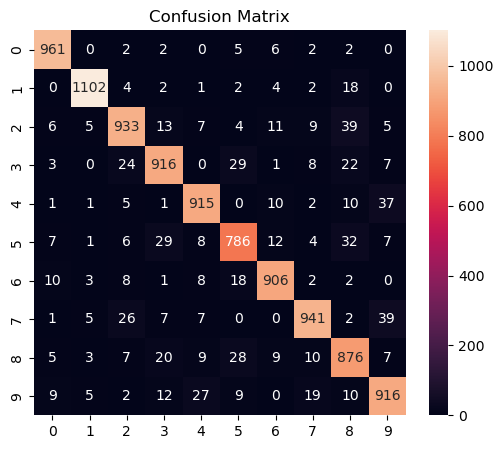

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# Warum Testdaten?
Testdaten sind wichtig, da diese daten enthalten, die das Model beim training noch nie gesehen hat. Dadurch wird eine echte anwendung zuverläassig simuliert. Außerdem verhindern Testdaten das Dass MOdell durch Overfitting zu gute Ergebnisse liefert.

---
# 7. potentielle Modellverbesserung
Statt linearer Klassifikation, nutzen wir jetzt mehrere schichten und nicht lineare aktivierungsfunktionen, wodurch komplexere musster erkannt werden können.
Das neue modell wird also nicht wie das alte model ausschließlich lineare Trennungen erkennen, sondern auch nichtlineare Zusammenhänge modellieren können

In [50]:
class ImprovedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

model2 = ImprovedModel().to(DEVICE)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE)

### Training

In [51]:
train_losses2 = []

for epoch in range(EPOCHS):
    model2.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses2.append(epoch_loss)

    print(f"[Improved] Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

[Improved] Epoch 1, Loss: 0.3422
[Improved] Epoch 2, Loss: 0.1412
[Improved] Epoch 3, Loss: 0.0959
[Improved] Epoch 4, Loss: 0.0716
[Improved] Epoch 5, Loss: 0.0573


### Evaluation

In [52]:
model2.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy2 = correct / total
print("Improved Accuracy:", accuracy2)

Improved Accuracy: 0.9752


### Vergleich von base Model und neum Model

In [53]:
print("Baseline Accuracy:", accuracy)
print("Improved Accuracy:", accuracy2)

Baseline Accuracy: 0.9252
Improved Accuracy: 0.9752


Der Vergleich zeigt dass das verbesserte Model auch eine besserer Accuracy erzielt als das alte Model